# Assignment 3: Linear Models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. The linearity that linear models refer to are specifically the parameters of the model. The predicted values are linear functions of the parameters.
2. After dropping one of the linearly dependent columns, you interpret the coefficient for a dummy variable as a comparison to the dropped label. 
3. No, because linear regression is very sensitive to outliers, and it's best use with continuous numerical values, rather than discrete categories or labels/
4. Signs that a linear model is overfitting are high training accuracy but low test accuracy, accuracy gap between training and test sets, and model instability.
5. Multicolinearity is when two or more explanatory variables are highly corrleted, or in 2SLS, when the instrument and regressor is highly correlated, or if the instrument is weak. So, the explanatory variable has very little variation and becomes a linear combination of other variables.
6. You can incorporate nonlinear relationships by using polynomial terms, transforming variables (log), and interaction terms where the effect of one variable depends on another.
7. An increase of x is associated wth a change of the slope coefficient in y.
8. A train/test split splits the data once, trains the model and evaluates it on the test set. Could be unstable and have high variance. The k-fold validation splits data in k equal parts, trains on k-1 parts, and tests on the last one. It repeats it k times and takes the average. The difference between them is that k-fold uses all the data for training and testing, so the estimate is more stable and reliable.
9. k is usually 5 or 10, but the rule of thumb is to use a larger k when the dataset is small, and smaller k when dataset is large.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [2]:
df = pd.read_csv("./data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750

Most expensive: Manhattan


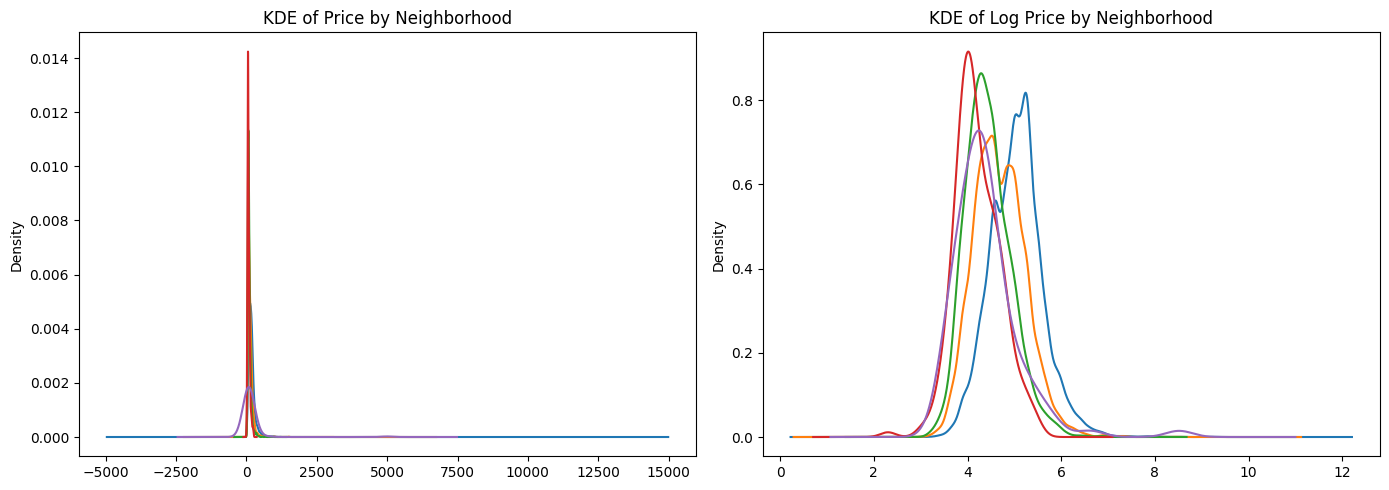

In [3]:
# 1.
neighborhood_avg = df.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print(neighborhood_avg)

most_expensive = neighborhood_avg['Price'].idxmax()
print(f"\nMost expensive: {most_expensive}")

fig, axes= plt.subplots(1, 2, figsize=(14, 5))
for neighborhood in df['Neighbourhood '].unique():
    data = df[df['Neighbourhood '] == neighborhood]['Price']
    data.plot.kde(ax=axes[0], label=neighborhood)
axes[0].set_title('KDE of Price by Neighborhood')

for neighborhood in df['Neighbourhood '].unique():
    data = np.log(df[df['Neighbourhood '] == neighborhood]['Price'])
    data.plot.kde(ax=axes[1], label=neighborhood)
axes[1].set_title('KDE of Log Price by Neighborhood')

plt.tight_layout()
plt.show()

In [4]:
#2
print(df['Neighbourhood '].value_counts())
print(pd.get_dummies(df['Neighbourhood ']).head())

# create dummy variables
X_neighborhood = pd.get_dummies(df['Neighbourhood '], dtype='int', drop_first=True)
X_neighborhood.head()
y = df['Price']

model = LinearRegression()
model = model.fit(X_neighborhood, y)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable':model.feature_names_in_, 'coefficients':model.coef_}))

# The relationship between the conditional group means and the estimated coefficients is estimated price + model intercept = means

print(neighborhood_avg)


Neighbourhood 
Manhattan        11763
Brooklyn          8487
Queens            1590
Bronx              217
Staten Island       96
Name: count, dtype: int64
   Bronx  Brooklyn  Manhattan  Queens  Staten Island
0  False     False       True   False          False
1  False      True      False   False          False
2  False     False       True   False          False
3  False      True      False   False          False
4  False     False       True   False          False
Model intercept: 75.27649769585331
        variable  coefficients
0       Brooklyn     52.470881
1      Manhattan    108.387789
2         Queens     21.580735
3  Staten Island     70.890169
                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.

In [5]:
# 3. 
y_price = df['Price']
X_rating = df[['Review Scores Rating']]

model_RSR = LinearRegression()
model_RSR.fit(X_rating, y_price)

print("Price ~ Review Scores Rating")
print(f"Intercept: {model_RSR.intercept_}")
print(f"Slope coefficient: {model_RSR.coef_[0]}")
print(f"\nFor each additional point in Review Scores Rating,")
print(f"the price increases by ${model_RSR.coef_[0]:.2f} per night.")
print(f"\nWhen Review Scores Rating = 0,")
print(f"the predicted price would be ${model_RSR.intercept_:.2f}.")

Price ~ Review Scores Rating
Intercept: 60.878390657123546
Slope coefficient: 1.0208266022674763

For each additional point in Review Scores Rating,
the price increases by $1.02 per night.

When Review Scores Rating = 0,
the predicted price would be $60.88.


In [6]:
# 4.
df_clean = df[['Price', 'Neighbourhood ', 'Review Scores Rating']].dropna()
X_combined = X_neighborhood.copy()
X_combined['Review Scores Rating'] = df_clean['Review Scores Rating'].values

model_combined = LinearRegression().fit(X_combined, y_price) 

print("Price ~ Review Scores Rating + Neighbourhood ")
print(f"Intercept: {model_combined.intercept_}")
print(f"RSR coefficient: {model_combined.coef_[-1]}")
print("Neighbourhood coefficients:")
for col, coef in zip (X_combined.columns[:-1], model_combined.coef_[:-1]):
    print(f"    {col}: ${coef:.2f}")

print("\nComparison:")
print(f"Review Scores Rating coefficient:")
print(f"  Model 3 (Rating): ${model_RSR.coef_[0]:.4f}")
print(f"  Model 4 (Rating + Neighbourhood): ${model_combined.coef_[-1]:.4f}")

Price ~ Review Scores Rating + Neighbourhood 
Intercept: -23.812561011672244
RSR coefficient: 1.0811164834598586
Neighbourhood coefficients:
    Brooklyn: $51.70
    Manhattan: $108.23
    Queens: $21.69
    Staten Island: $71.77

Comparison:
Review Scores Rating coefficient:
  Model 3 (Rating): $1.0208
  Model 4 (Rating + Neighbourhood): $1.0811


In [7]:
# 5.
rating = df_clean['Review Scores Rating']

# Create interactions: dummy * rating for each neighborhood
X_interactions = X_neighborhood.copy()
for col in X_neighborhood.columns:
    X_interactions[f'{col}_rating'] = X_neighborhood[col] * rating

# rating for the reference neighborhood
X_interactions['rating_reference'] = rating

model_interactions = LinearRegression()
model_interactions.fit(X_interactions, y_price)

print("Price ~ Constant + Separate Slopes for Each Neighborhood")
print(f"Intercept: ${model_interactions.intercept_:.2f}")

print("Slope coefficients for Review Scores Rating by neighborhood:")

neighborhoods = sorted(df['Neighbourhood '].unique())
ref_neighborhood = neighborhoods[0]

# Reference neighborhood slope
print(f"{ref_neighborhood} (reference): ${model_interactions.coef_[-1]:.4f}")

# Other neighborhoods' slopes
for i, col in enumerate(X_neighborhood.columns):
    slope = model_interactions.coef_[i] + model_interactions.coef_[-1]  # dummy coef + rating coef
    neighborhood_name = col
    print(f"{neighborhood_name}: ${slope:.4f}")

print("Are the slopes similar across neighborhoods?")

slopes = {}
slopes[ref_neighborhood] = model_interactions.coef_[-1]
for i, col in enumerate(X_neighborhood.columns):
    slopes[col] = model_interactions.coef_[i] + model_interactions.coef_[-1]

slope_values = list(slopes.values())
slope_range = max(slope_values) - min(slope_values)
slope_std = np.std(slope_values)

print(f"Slope range: ${slope_range:.4f}")
print(f"Slope standard deviation: ${slope_std:.4f}")

print(" Slopes vary significantly across neighborhoods")

Price ~ Constant + Separate Slopes for Each Neighborhood
Intercept: $22.64
Slope coefficients for Review Scores Rating by neighborhood:
Bronx (reference): $0.5743
Brooklyn: $-15.8187
Manhattan: $41.8897
Queens: $28.8340
Staten Island: $2963.6454
Are the slopes similar across neighborhoods?
Slope range: $2979.4640
Slope standard deviation: $1180.0854
 Slopes vary significantly across neighborhoods


In [8]:
# 6. 
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error

# Price ~ Review Scores Rating
X_model3 = df_clean[['Review Scores Rating']]

# Price ~ Neighbourhood + Review Scores Rating
X_model4 = X_neighborhood.copy()
X_model4['Review Scores Rating'] = df_clean['Review Scores Rating']

# Price ~ Constant + Separate slopes for each neighborhood
rating = df_clean['Review Scores Rating']
X_model5 = X_neighborhood.copy()
for col in X_neighborhood.columns:
    X_model5[f'{col}_rating'] = X_neighborhood[col] * rating
X_model5['rating_ref'] = rating

cv = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Evaluate each model
models = {
    'Model 3 (Rating)': (X_model3, 'Price ~ Review Scores Rating'),
    'Model 4 (Rating + Neighbourhood)': (X_model4, 'Price ~ Neighbourhood + Review Scores Rating'),
    'Model 5 (Separate slopes)': (X_model5, 'Price ~ Separate slopes by neighbourhood')
}

print("CROSS VALIDATION")

results = {}
for name, (X_data, description) in models.items():
    # Calculate cross-validated MSE (negative because sklearn returns negative MSE)
    cv_mse = -cross_val_score(LinearRegression(), X_data, y, cv=cv, scoring=mse_scorer)
    cv_rmse = np.sqrt(cv_mse)

    results[name] = {
        'MSE_mean': cv_mse.mean(),
        'MSE_std': cv_mse.std(),
        'RMSE_mean': cv_rmse.mean(),
        'RMSE_std': cv_rmse.std(),
    }

    print(f"\n{name}")
    print(f"Description: {description}")
    print(f"Cross-validated MSE:  {cv_mse.mean():.2f} +- {cv_mse.std():.2f}")
    print(f"Cross-validated RMSE: ${cv_rmse.mean():.2f} +- ${cv_rmse.std():.2f}")

print("\nMODEL COMPARISON")
print("Based on cross-validated RMSE (lower is better):")
sorted_models = sorted(results.items(), key=lambda x: x[1]['RMSE_mean'])
for i, (name, metrics) in enumerate(sorted_models, 1):
    print(f"{i}. {name}: ${metrics['RMSE_mean']:.2f} +- ${metrics['RMSE_std']:.2f}")

CROSS VALIDATION

Model 3 (Rating)
Description: Price ~ Review Scores Rating
Cross-validated MSE:  22078.79 +- 12029.64
Cross-validated RMSE: $144.17 +- $35.95

Model 4 (Rating + Neighbourhood)
Description: Price ~ Neighbourhood + Review Scores Rating
Cross-validated MSE:  21070.14 +- 11921.86
Cross-validated RMSE: $140.52 +- $36.40

Model 5 (Separate slopes)
Description: Price ~ Separate slopes by neighbourhood
Cross-validated MSE:  21328.18 +- 11841.51
Cross-validated RMSE: $141.57 +- $35.87

MODEL COMPARISON
Based on cross-validated RMSE (lower is better):
1. Model 4 (Rating + Neighbourhood): $140.52 +- $36.40
2. Model 5 (Separate slopes): $141.57 +- $35.87
3. Model 3 (Rating): $144.17 +- $35.95


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


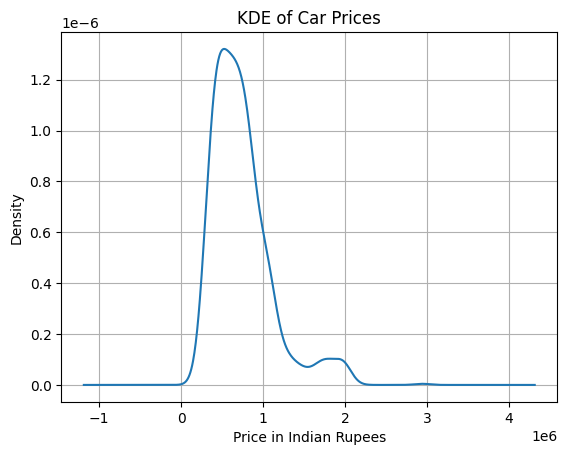

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


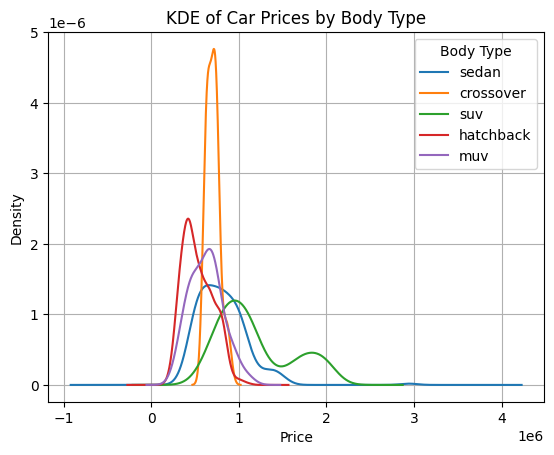

Most expensive: suv ($1176495.15)
Most variance: suv ($174288739000.71)


In [9]:
# 1.
cars_df = pd.read_csv("./data/cars_hw.csv")
summary = cars_df['Price'].describe()
print(summary)

cars_df['Price'].plot.kde()
plt.xlabel('Price in Indian Rupees')
plt.title('KDE of Car Prices')
plt.grid(True)
plt.show()

grouped = cars_df.groupby('Body_Type')['Price'].describe()
print(grouped)

for body_type in cars_df['Body_Type'].unique():
    types = cars_df[cars_df['Body_Type'] == body_type]['Price']
    types.plot.kde(label=body_type)

plt.xlabel('Price')
plt.title('KDE of Car Prices by Body Type')
plt.legend(title='Body Type')
plt.grid(True)
plt.show()

mean_prices = cars_df.groupby('Body_Type')['Price'].mean().sort_values(ascending=False)
most_expensive = mean_prices.index[0]
print(f"Most expensive: {most_expensive} (${mean_prices.iloc[0]:.2f})")

variances = cars_df.groupby('Body_Type')['Price'].var().sort_values(ascending=False)
most_variable = variances.index[0]
print(f"Most variance: {most_variable} (${variances.iloc[0]:.2f})")


In [10]:
# 2.

# create dummy variables
X_capacity = cars_df[['Seating_Capacity']]
y_carprice = cars_df['Price']

model_cars = LinearRegression()
model_cars = model_cars.fit(X_capacity, y_carprice)

print(f"Slope coefficient: ${model_cars.coef_[0]:.2f}")
print(f"For each additional seat, the price increases by ${model_cars.coef_[0]}")

X_categorical = pd.get_dummies(cars_df['Seating_Capacity'], drop_first=True, dtype=int)
model_categorical = LinearRegression()
model_categorical.fit(X_categorical, y_carprice)

group_means = cars_df.groupby('Seating_Capacity')['Price'].mean()

# linearity
seating_capacities = sorted(cars_df['Seating_Capacity'].unique())
print("Price differences:")
differences = []
for i in range(1, len(seating_capacities)):
    prev_seats = seating_capacities[i-1]
    curr_seats = seating_capacities[i]
    diff = group_means[curr_seats] - group_means[prev_seats]
    differences.append(diff)

# Calculate coefficient of variation
if len(differences) > 1:
    diff_mean = np.mean(differences)
    diff_std = np.std(differences)
    cv = diff_std / diff_mean
    print(f"\nCoefficient of variation: {cv:.4f}")

print("Price differences are not linear in seating capacity")

Slope coefficient: $59268.00
For each additional seat, the price increases by $59267.99803672175
Price differences:

Coefficient of variation: 9.9849
Price differences are not linear in seating capacity


In [27]:
# 3.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

 
year = 2026
cars_df['Age'] = year - cars_df['Make_Year']

X_age = cars_df[['Age']].values
y = cars_df['Price'].values

cv10 = KFold(n_splits=10, shuffle=True)

max_degree = 6
cv10_results = {}

for degree in range(1, max_degree + 1):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_age)

    mse_scores = -cross_val_score(LinearRegression(), X_poly, y, cv=cv10, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(mse_scores)
    r2_scores = cross_val_score(LinearRegression(), X_poly, y, cv=cv10, scoring='r2')

    cv10_results[degree] = {
        'MSE_mean': mse_scores.mean(),
        'MSE_std': mse_scores.std(),
        'RSME_mean': rmse_scores.mean(),
        'RSME_std': rmse_scores.std()

    }

    print(f"\nDegree {degree}: CV MSE: {mse_scores.mean():.2f}")
    print(f"  CV RMSE: ${rmse_scores.mean():.2f} ± ${rmse_scores.std():.2f}")


optimal_degree = min(cv10_results.keys(), key=lambda k: cv10_results[k]['RSME_mean'])
print(f"\nOptimal degree: {optimal_degree}")

poly_final = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_final = poly_final.fit_transform(X_age)
model_final = LinearRegression()
model_final.fit(X_final, y)


Degree 1: CV MSE: 97874818516.35
  CV RMSE: $309768.96 ± $43795.09

Degree 2: CV MSE: 97484674481.65
  CV RMSE: $310497.13 ± $32805.56

Degree 3: CV MSE: 97032750482.99
  CV RMSE: $309538.59 ± $34908.65

Degree 4: CV MSE: 97472433821.71
  CV RMSE: $310466.45 ± $32909.20

Degree 5: CV MSE: 96166122111.53
  CV RMSE: $307648.80 ± $38965.85

Degree 6: CV MSE: 95702620526.84
  CV RMSE: $307507.74 ± $33787.68

Optimal degree: 6


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


/tmp/ipykernel_25508/1675985611.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


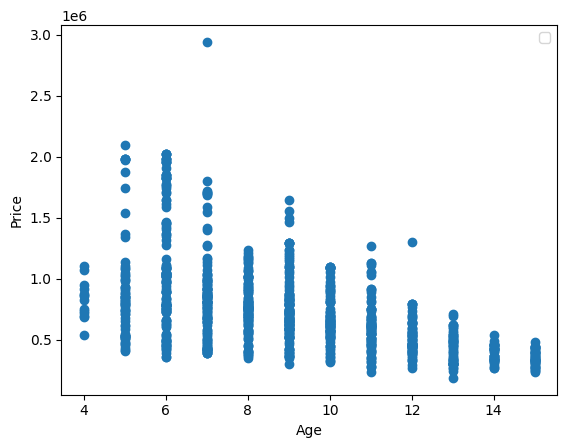

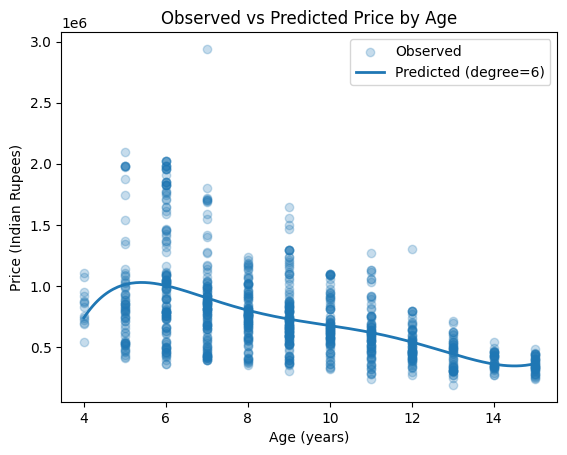

RMSE: 307857.61
R2:   0.30
R2 is < 0.5, model fit is weak. There is substantial variance unexplained.


In [29]:
# 4.   4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?
plt.scatter(cars_df['Age'], cars_df['Price'])
plt.xlabel('Age')
plt.ylabel('Price')
plt.legend()
plt.show()

age_grid = np.linspace(cars_df['Age'].min(), cars_df['Age'].max(), 200).reshape(-1, 1)
age_grid_poly = poly_final.transform(age_grid)
predicted_price = model_final.predict(age_grid_poly)

plt.scatter(cars_df['Age'], cars_df['Price'], alpha=0.25, label='Observed')
plt.plot(age_grid, predicted_price, linewidth=2, label=f'Predicted (degree={optimal_degree})')
plt.xlabel('Age (years)')
plt.ylabel('Price (Indian Rupees)')
plt.title('Observed vs Predicted Price by Age')
plt.legend()
plt.show()

y_true = cars_df['Price']
y_pred = model_final.predict(poly_final.transform(cars_df[['Age']].values))
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
print(f"R2:   {r2_score(y_true, y_pred):.2f}")

print("R2 is < 0.5, model fit is weak. There is substantial variance unexplained.")

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
